# Imports

In [2]:
import h5py
import numpy as np
import os
import json
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import importlib

import axolotl_utils_ram
importlib.reload(axolotl_utils_ram)
from axolotl_utils_ram import extract_snippets_fast_ram, compute_and_plot_sta

import plot_ei_waveforms
importlib.reload(plot_ei_waveforms)
import plot_ei_waveforms as pew

import compute_sta_from_spikes
importlib.reload(compute_sta_from_spikes)

import collision_utils
importlib.reload(collision_utils)
from collision_utils import median_ei_adaptive



# import joint_utils
# importlib.reload(joint_utils)



# Load data

In [3]:
#### RAW DATA AND BASELINES ##### 

# dat_path = "/Volumes/Lab/Users/alexth/axolotl/201703151_data001.dat"
dat_path = "/Volumes/Lab/Users/alexth/axolotl/201808079/data001.dat"

n_channels = 512
dtype = np.int16

file_size_bytes = os.path.getsize(dat_path)
total_samples = file_size_bytes // (np.dtype(dtype).itemsize * n_channels)

print("Loading data")

raw_data = np.fromfile(dat_path, dtype=dtype, count=total_samples * n_channels)
raw_data = raw_data.reshape((total_samples, n_channels))  # shape: [T, C]

print("Finished Loading data")

# baseline_path = "/Volumes/Lab/Users/alexth/axolotl/201703151_data001_baseline_derivative_20k.json"
baseline_path = "/Volumes/Lab/Users/alexth/axolotl/201808079/data001_baseline_derivative_20k.json"

segment_len = 20_000
if os.path.exists(baseline_path):
    print(f"Loading baselines")
    with open(baseline_path, 'r') as f:
        data = json.load(f)
    baselines = np.array(data['baselines'], dtype=np.float32)
else:
    print(f"Computing baselines")
    baselines = axolotl_utils_ram.compute_baselines_int16_deriv_robust(raw_data, segment_len=segment_len, diff_thresh=10, trim_fraction=0.15) # shape (512, 360)

    with open(baseline_path, 'w') as f:
        json.dump({
            'baselines': baselines.tolist(),
        }, f)

print("subtracting baselines")

axolotl_utils_ram.subtract_segment_baselines_int16(raw_data=raw_data,
                                     baselines_f32=baselines,
                                     segment_len=segment_len) 

print("Finished subtracting baselines")

#### EI POSITIONS ##### 
h5_in_path = '/Volumes/Lab/Users/alexth/axolotl/201703151_kilosort_data001_spike_times.h5'  # from MATLAB export, to get EI positions

with h5py.File(h5_in_path, 'r') as f:
    ei_positions = f['/ei_positions'][:].T  # shape becomes [512 x 2]

print("loaded EI positions")

#### TRIGGERS #####
# triggers_mat_path='/Volumes/Lab/Users/alexth/axolotl/trigger_in_samples_201703151.mat'
# triggers_sec = loadmat(triggers_mat_path)['triggers'].flatten()

path = '/Volumes/Lab/Users/alexth/axolotl/201808079/data006_triggers.h5'
# path = '/Volumes/Lab/Users/alexth/axolotl/201808079/data001_triggers.h5'
# path = '/Volumes/Lab/Users/alexth/axolotl/201808079/data002_triggers.h5'
with h5py.File(path, 'r') as h5:
    triggers_sec = h5['/triggers'][...]         # shape (4303, 1) or (4303,)
triggers_sec = np.ravel(triggers_sec).astype(np.float64)  # 1D float64

print("loaded triggers")

#### SPIKES #####

# path = '/Volumes/Lab/Users/alexth/axolotl/2017-03-15-1_data001_all_spikes.h5'
path = '/Volumes/Lab/Users/alexth/axolotl/2018-08-07-9_data001_all_spikes.h5'
with h5py.File(path, "r") as h5:
    # Make this a 1D array of scalars
    cell_ids = np.array(h5["/cell_ids"], dtype=np.int64).ravel()
    n_cells = cell_ids.shape[0]

    for k in range(n_cells):
        cell_id = int(cell_ids[k])   # now safe, no warning
        ds_name = f'/spikes/cell_{k+1}'
        sp = h5[ds_name][:].astype(np.int64)
        if sp.size == 1 and sp[0] == -1:
            sp = sp[:0]  # treat sentinel as empty
        # sp are sample indices at 20 kHz for this cell


print("loaded KS spikes")



Loading data
Finished Loading data
Loading baselines
subtracting baselines
Finished subtracting baselines
loaded EI positions
loaded triggers
loaded KS spikes


# Analyze unit

Found 949 cells in H5
Selected cell_idx=81, Vision cell_id=108, spikes=23621
Using 500 spikes for EI (subset)
snips_full shape: (512, 121, 500), valid_times_full: 500
Main channel: 53, peak sample index on that channel: 40


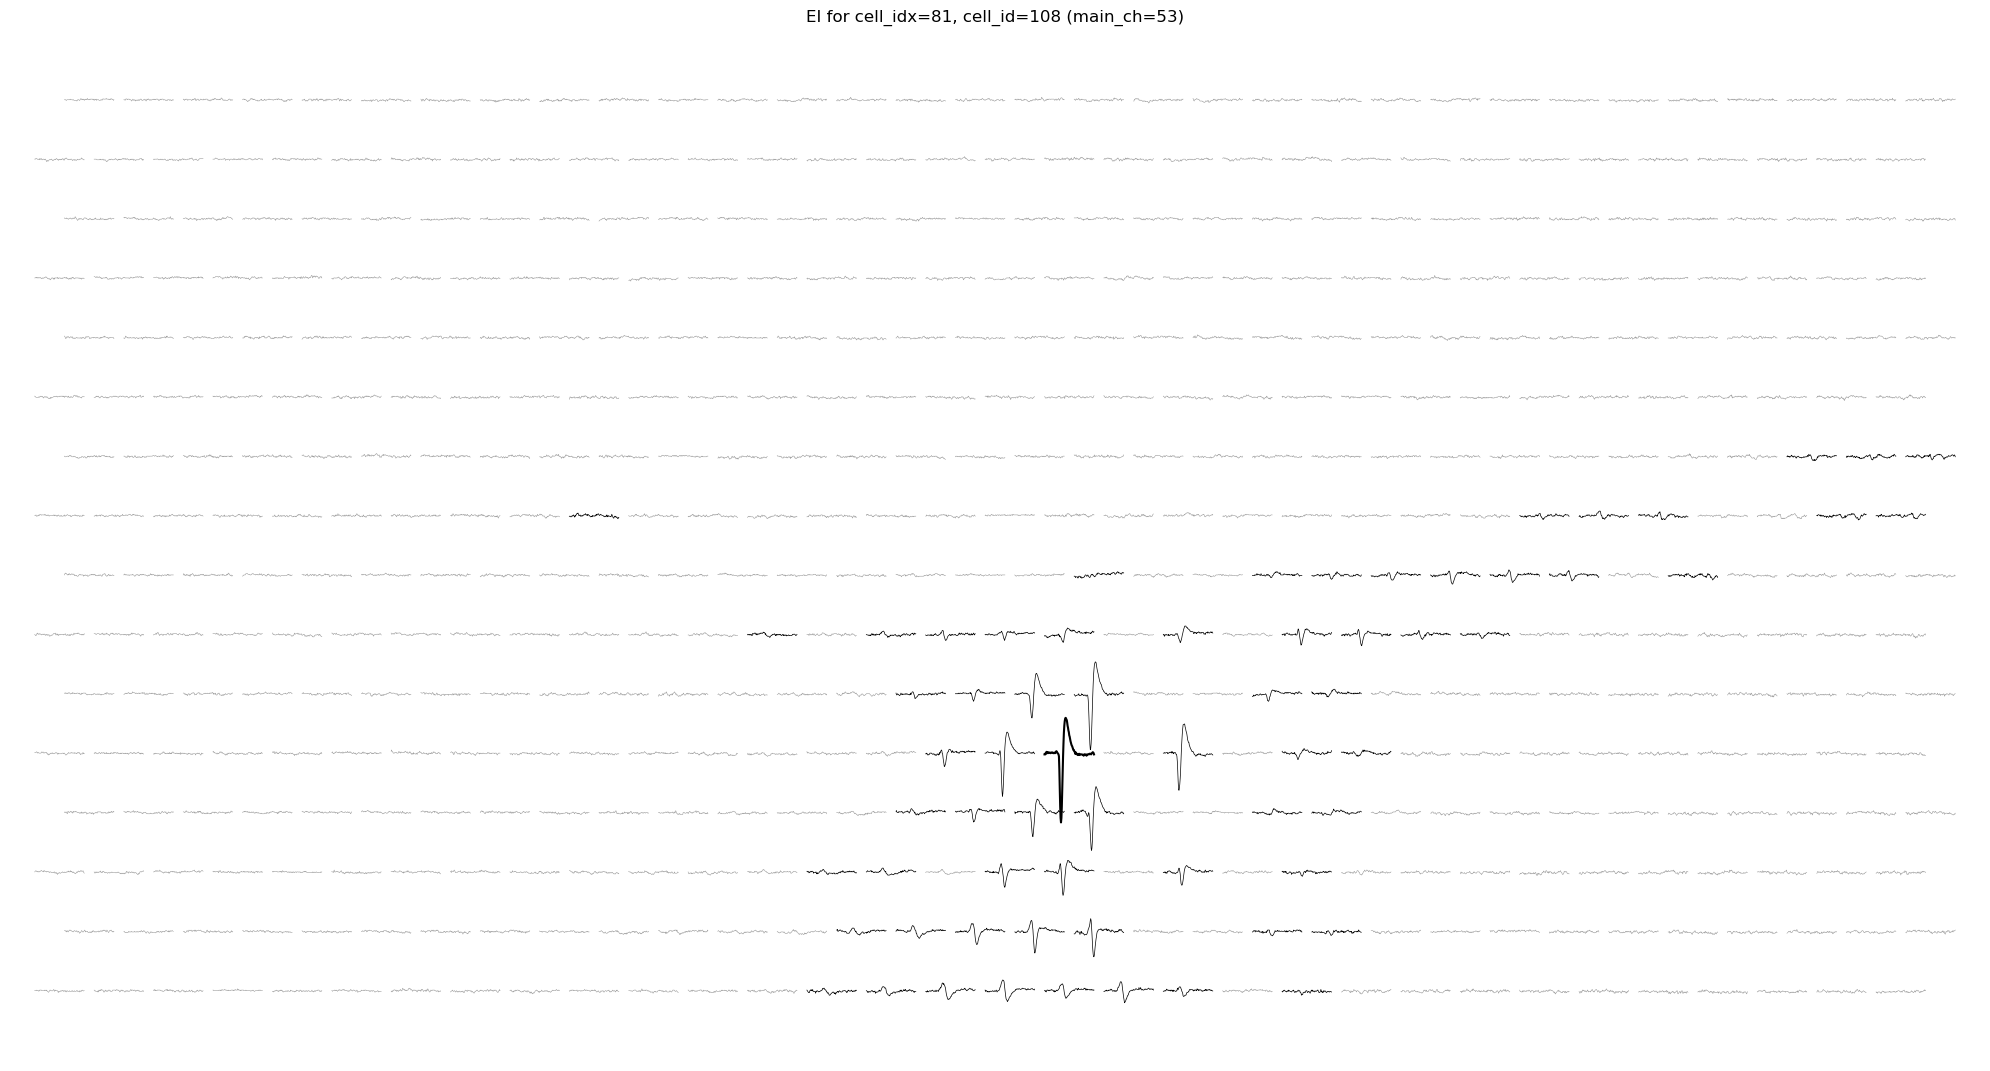

snips_main shape: (1, 61, 23621), valid_times_main: 23621


In [22]:
cell_idx = 81   # interesting 2017-03-15-1_data001: 408, 446, 717


# h5_path = '/Volumes/Lab/Users/alexth/axolotl/2017-03-15-1_data001_all_spikes.h5'
h5_path = '/Volumes/Lab/Users/alexth/axolotl/2018-08-07-9_data001_all_spikes.h5'

with h5py.File(h5_path, "r") as h5:
    # cell_ids saved as 1D or 2D -> flatten to 1D
    cell_ids = np.array(h5["/cell_ids"]).ravel()
    n_cells = cell_ids.shape[0]
    print(f"Found {n_cells} cells in H5")

    # ---- choose a unit by 1-based index (matches MATLAB's k) ----
    assert 1 <= cell_idx <= n_cells

    ds_name = f"/spikes/cell_{cell_idx}"
    sp_samp = np.array(h5[ds_name], dtype=np.int64).ravel()   # sample indices at 20 kHz

    # Handle empty spike trains (sentinel -1)
    if sp_samp.size == 1 and sp_samp[0] == -1:
        raise ValueError(f"Cell {cell_idx} (ID {cell_ids[cell_idx-1]}) has an empty spike train.")

    cell_id = int(cell_ids[cell_idx - 1])
    print(f"Selected cell_idx={cell_idx}, Vision cell_id={cell_id}, spikes={sp_samp.size}")


# --------------------------------------------------
# 2. Random subset of ~500 spikes for EI, full array [-40, 80]
# --------------------------------------------------
rng = np.random.default_rng(12345)  # deterministic for debugging
n_total = sp_samp.size
n_sub = min(500, n_total)

sub_indices = rng.choice(n_total, size=n_sub, replace=False)
spike_times_sub = np.sort(sp_samp[sub_indices])   # sort for nicer behavior

print(f"Using {spike_times_sub.size} spikes for EI (subset)")

# All channels
n_channels = raw_data.shape[1]
all_channels = np.arange(n_channels, dtype=np.int32)

window_ei = (-40, 80)  # [pre, post] in samples

snips_full, valid_times_full = extract_snippets_fast_ram(
    raw_data=raw_data,
    spike_times=spike_times_sub,
    window=window_ei,
    selected_channels=all_channels
)
# snips_full: [C, L, N_valid]
print(f"snips_full shape: {snips_full.shape}, valid_times_full: {valid_times_full.size}")

# --------------------------------------------------
# 3. Compute EI and find main channel & peak index
# --------------------------------------------------
# EI via robust median over spikes
ei = median_ei_adaptive(snips_full).astype(np.float32)   # [C, L]

# main channel = channel with deepest negative trough
mins = ei.min(axis=1)                 # [C], most negative is smallest
main_ch = int(np.argmin(mins))
peak_idx = int(np.argmin(ei[main_ch]))  # sample index of most negative sample on that channel

print(f"Main channel: {main_ch}, peak sample index on that channel: {peak_idx}")

# --------------------------------------------------
# 4. Plot EI with plot_ei_waveforms
# --------------------------------------------------
plt.figure(figsize=(20, 12))
pew.plot_ei_waveforms(
    ei,
    ei_positions,
    ref_channel=main_ch,
    scale=70.0,
    box_height=1.0,
    box_width=50.0
)
plt.title(f"EI for cell_idx={cell_idx}, cell_id={cell_id} (main_ch={main_ch})")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Extract snippets for ALL spikes on main channel, window [-20, 40]
# --------------------------------------------------
window_main = (-20, 40)

snips_main, valid_times_main = extract_snippets_fast_ram(
    raw_data=raw_data,
    spike_times=sp_samp,
    window=window_main,
    selected_channels=np.array([main_ch], dtype=np.int32)
)
# snips_main: [1, L_main, N_valid_main]
print(f"snips_main shape: {snips_main.shape}, valid_times_main: {valid_times_main.size}")

# For convenience you can squeeze:
# waveform_main = snips_main[0]  # [L_main, N_valid_main]


Main-channel snippets shape: L=61, N=23621
Amplitude window in snippet: samples [18:23) (center=20, relative time 0)
Amplitude stats (main channel): min=-70.0, max=462.0
Using fixed bands: shallow=2000, mid=2000, tall=2000


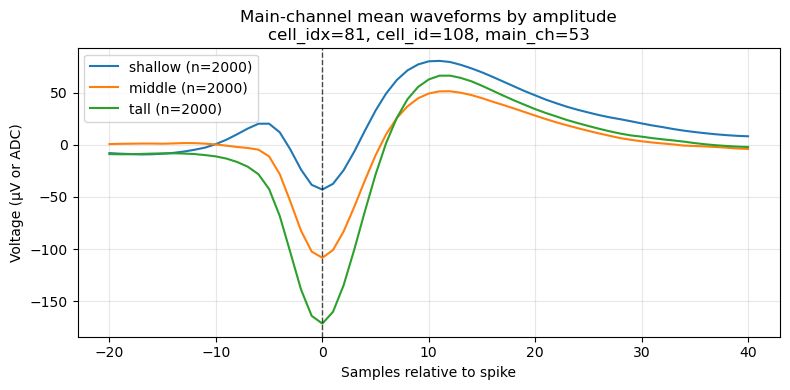

In [26]:
band_size = 2000
# --------------------------------------------------
# 0. Assume these already exist from previous steps:
#   snips_main: [1, L_main, N]
#   window_main = (-20, 40)
#   peak_idx: trough index on EI using window_ei = (-40, 80)
#   main_ch, cell_idx, cell_id defined earlier (optional)
# --------------------------------------------------

# Just to be explicit here:
window_ei = (-40, 80)   # same as used when computing EI
pre_ei, post_ei = window_ei
pre_main, post_main = window_main

# Waveforms on main channel: shape [L_main, N_spikes]
waveforms = snips_main[0]   # [L_main, N]
L_main, N_main = waveforms.shape
print(f"Main-channel snippets shape: L={L_main}, N={N_main}")

# --------------------------------------------------
# 1. Compute index of EI trough within main-channel snippet
#    EI trough time relative to spike: t_peak = pre_ei + peak_idx
#    Corresponding index in window_main: idx = t_peak - pre_main
# --------------------------------------------------
t_peak = pre_ei + peak_idx          # time (samples) relative to spike
peak_main_idx = int(t_peak - pre_main)

# Make sure ±2 around this index is inside snippet bounds
if peak_main_idx < 2 or peak_main_idx > L_main - 3:
    print(f"Warning: peak_main_idx={peak_main_idx} near edge, clamping.")
    peak_main_idx = max(2, min(L_main - 3, peak_main_idx))

amp_half_win = 2
start_idx = peak_main_idx - amp_half_win      # inclusive
end_idx   = peak_main_idx + amp_half_win + 1  # exclusive

print(f"Amplitude window in snippet: samples [{start_idx}:{end_idx}) "
      f"(center={peak_main_idx}, relative time {pre_main + peak_main_idx})")

# --------------------------------------------------
# 2. Amplitude per spike (more negative ⇒ larger amplitude)
# --------------------------------------------------
# slice: [window_len, N_spikes]
window_slice = waveforms[start_idx:end_idx, :]        # shape [(2*amp_half_win+1), N]
# amplitude = positive magnitude of negative trough
amps = -np.min(window_slice, axis=0)                  # [N]
print(f"Amplitude stats (main channel): min={amps.min():.1f}, max={amps.max():.1f}")

# Sort spikes by amplitude (ascending: shallow → tall)
order = np.argsort(amps)
N = N_main

# --------------------------------------------------
# 3. Define three bands: shallow, middle, tall
# --------------------------------------------------
if N >= band_size*3:
    idx_shallow = order[:band_size]
    idx_tall    = order[-band_size:]
    mid_start   = (N - band_size) // 2
    idx_middle  = order[mid_start:mid_start + band_size]
    print(f"Using fixed bands: shallow={idx_shallow.size}, mid={idx_middle.size}, tall={idx_tall.size}")
else:
    # Split into 3 contiguous groups of nearly equal size
    bands = np.array_split(order, 3)
    idx_shallow, idx_middle, idx_tall = bands
    print(f"Total spikes {N} < 3000 → split into thirds:")
    print(f"  shallow={idx_shallow.size}, mid={idx_middle.size}, tall={idx_tall.size}")

# --------------------------------------------------
# 4. Compute mean waveform for each band
# --------------------------------------------------
mean_shallow = waveforms[:, idx_shallow].mean(axis=1)   # [L_main]
mean_middle  = waveforms[:, idx_middle].mean(axis=1)    # [L_main]
mean_tall    = waveforms[:, idx_tall].mean(axis=1)      # [L_main]

# Time axis in samples relative to spike
t = np.arange(pre_main, post_main + 1, dtype=int)
assert t.shape[0] == L_main

# --------------------------------------------------
# 5. Plot overlay of band mean waveforms
# --------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(t, mean_shallow, label=f"shallow (n={idx_shallow.size})", linewidth=1.5)
plt.plot(t, mean_middle,  label=f"middle (n={idx_middle.size})",  linewidth=1.5)
plt.plot(t, mean_tall,    label=f"tall (n={idx_tall.size})",      linewidth=1.5)

plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7)

plt.xlabel("Samples relative to spike")
plt.ylabel("Voltage (µV or ADC)")
plt.title(f"Main-channel mean waveforms by amplitude\n"
          f"cell_idx={cell_idx}, cell_id={cell_id}, main_ch={main_ch}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ALL:     23621 spikes
SHALLOW: 2000 spikes
MIDDLE:  2000 spikes
TALL:    2000 spikes

=== Band: all (N=23621) ===


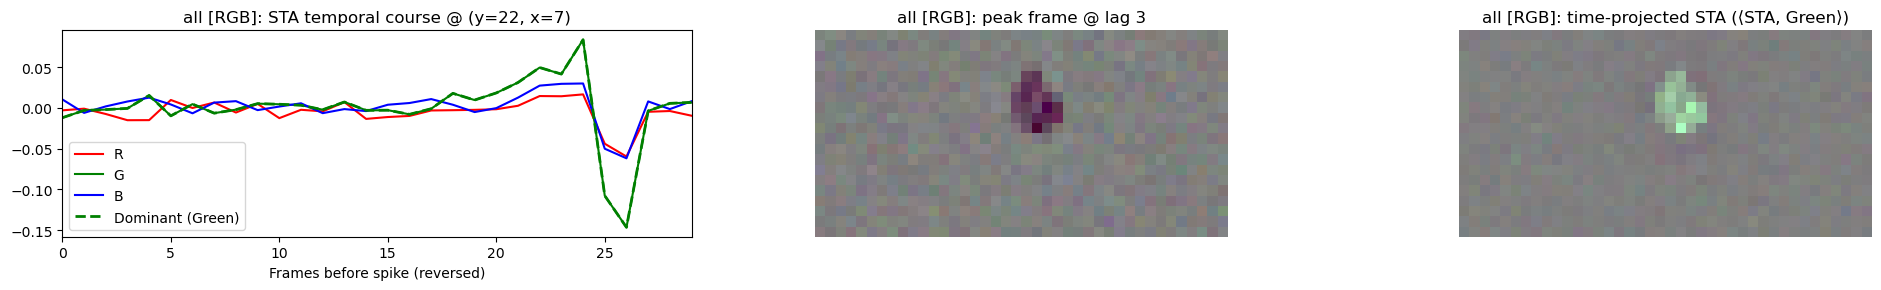

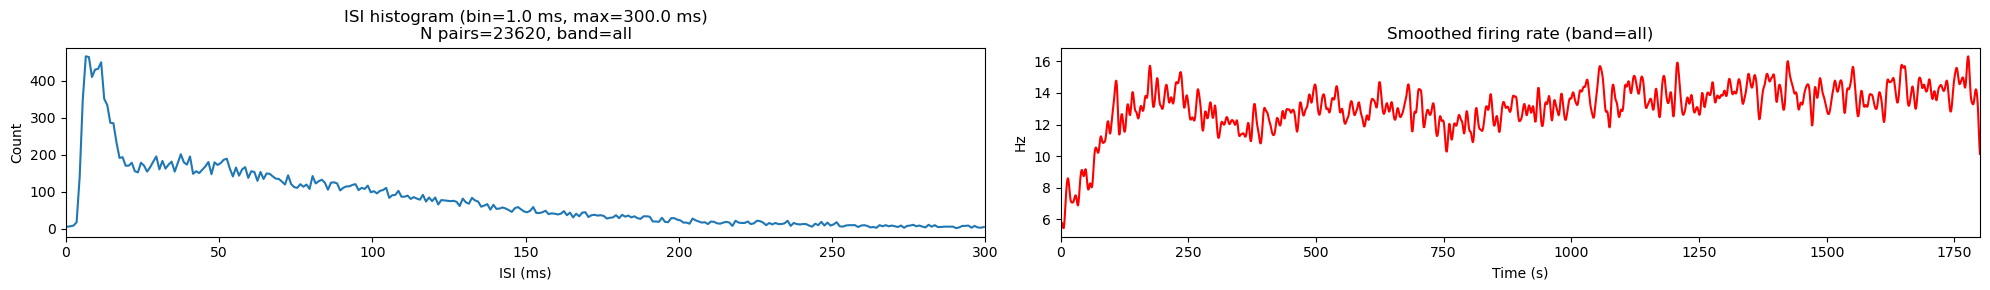


=== Band: shallow (N=2000) ===


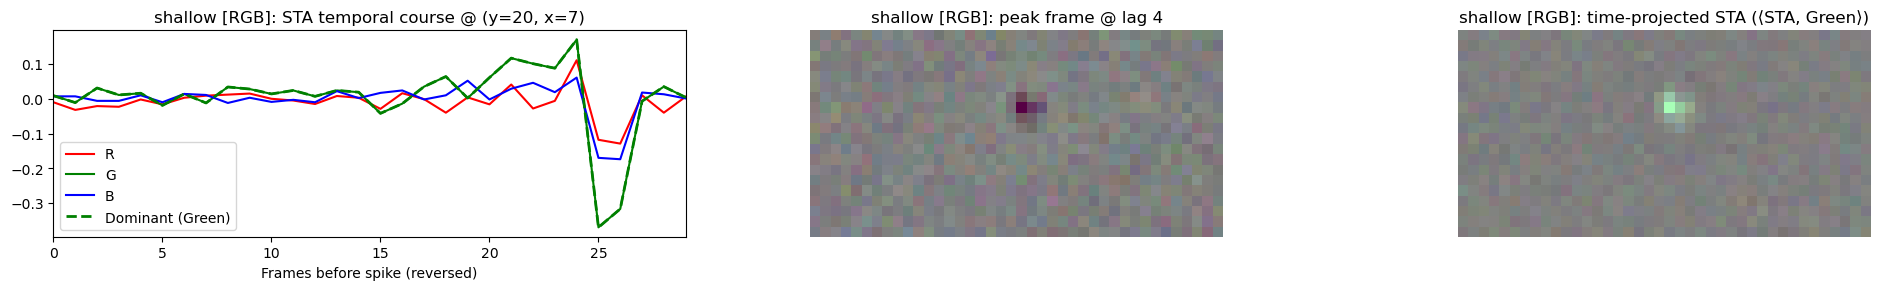

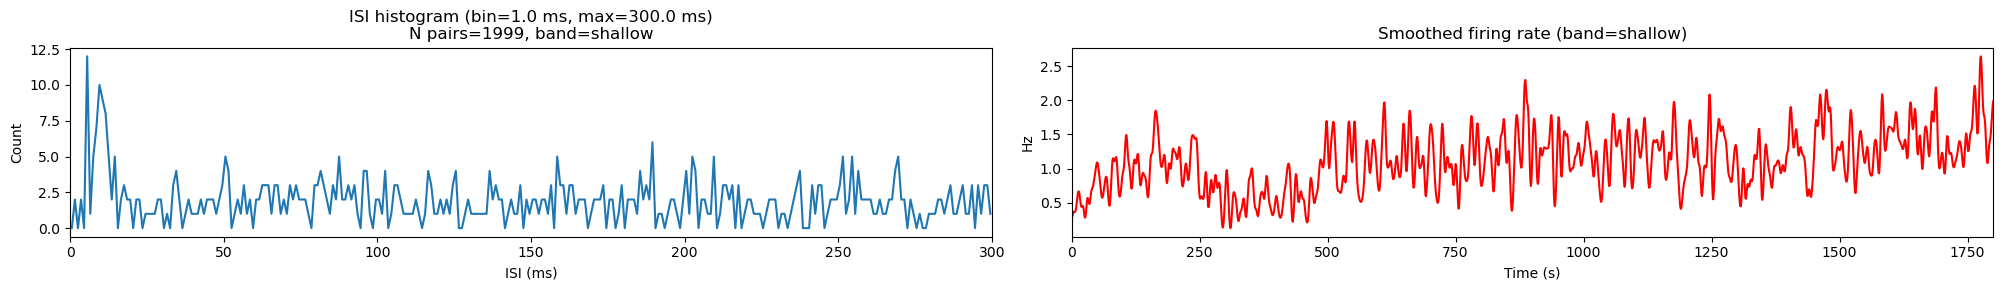


=== Band: middle (N=2000) ===


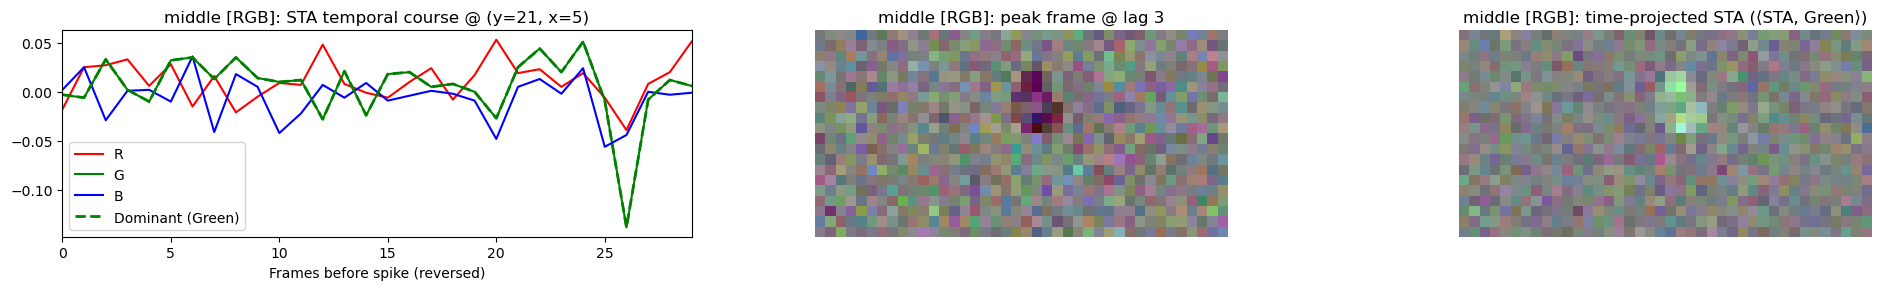

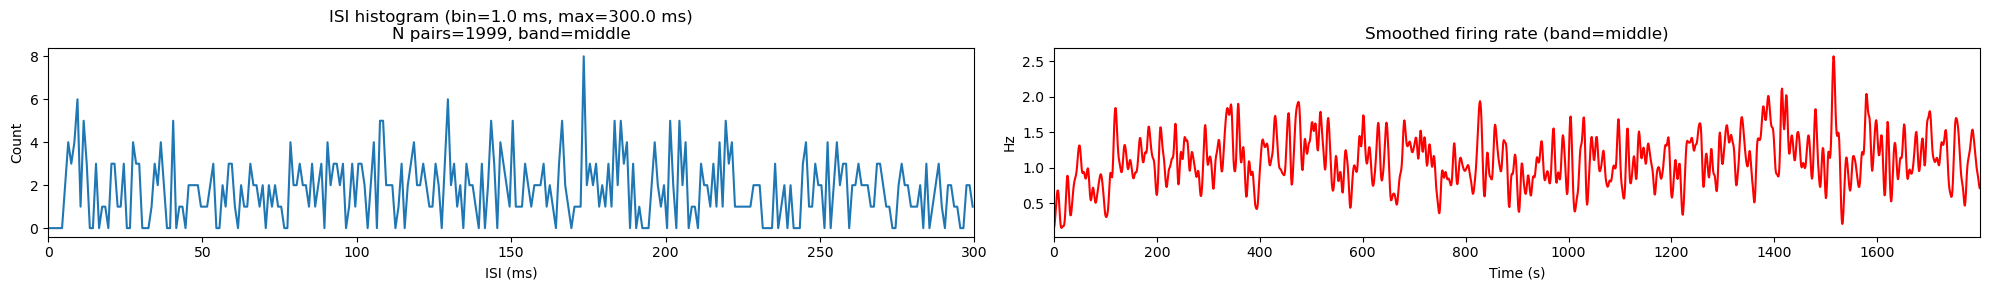


=== Band: tall (N=2000) ===


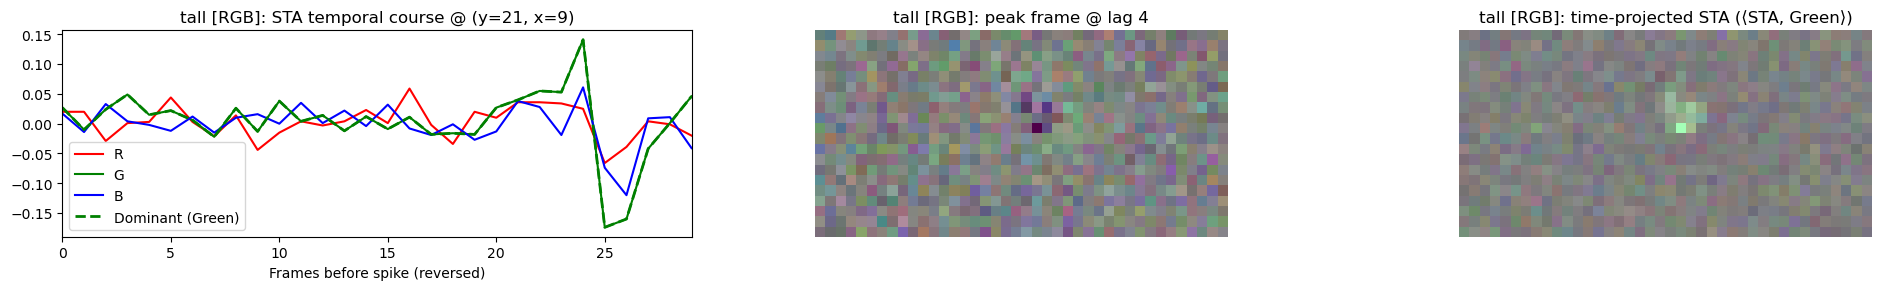

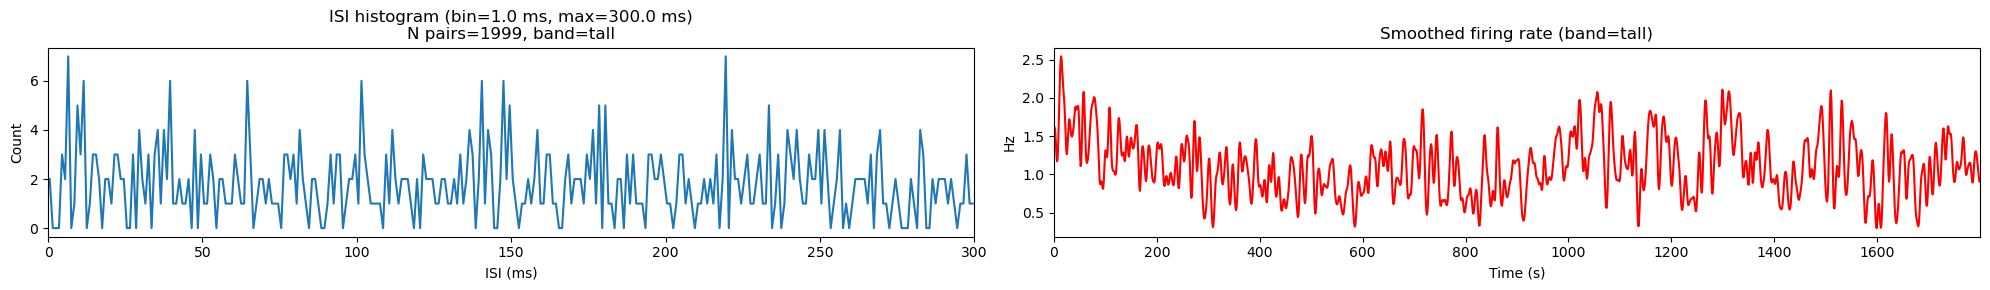

red power: 7.670e-03
green power: 4.679e-02
blue power: 9.995e-03
Dominant color channel in ALL band: green


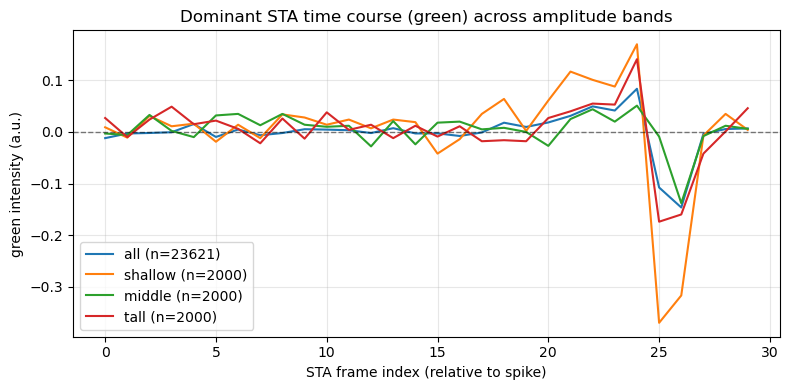

In [27]:
# --------------------------------------------------
# 0. Build spike time arrays (in samples) for each band
#    NOTE: these are aligned to valid_times_main, not original sp_samp
# --------------------------------------------------
spikes_all     = np.sort(valid_times_main)                     # all spikes with valid snippets
spikes_shallow = np.sort(valid_times_main[idx_shallow])
spikes_middle  = np.sort(valid_times_main[idx_middle])
spikes_tall    = np.sort(valid_times_main[idx_tall])

print(f"ALL:     {spikes_all.size} spikes")
print(f"SHALLOW: {spikes_shallow.size} spikes")
print(f"MIDDLE:  {spikes_middle.size} spikes")
print(f"TALL:    {spikes_tall.size} spikes")

# --------------------------------------------------
# 1. STA parameters (match your old code)
# --------------------------------------------------
STA_DEPTH   = 30
STA_OFFSET  = 2
STA_CHUNK   = 1000
STA_REFRESH = 2
STA_SEED    = 11111
W, H        = 20, 40   # stimulus width/height (as in your existing setup)

# ISI / rate params (should already exist in your notebook; adjust as needed)
max_ms       = 300.0
bin_width_ms = 1.0
dt_ms        = 1000.0   # bin for firing rate (ms)
sigma_ms     = 2500.0   # smoothing kernel width (ms)
sample_rate_hz = 20_000 # sampling in Hz

bands = {
    "all":     spikes_all,
    "shallow": spikes_shallow,
    "middle":  spikes_middle,
    "tall":    spikes_tall,
}

# --------------------------------------------------
# 2. Loop over bands: STA + ISI + rate + plots
# --------------------------------------------------

band_tcs = {}  # will store time courses per band


for label, spikes_in_samples in bands.items():
    if spikes_in_samples.size == 0:
        print(f"[{label}] no spikes, skipping")
        continue

    print(f"\n=== Band: {label} (N={spikes_in_samples.size}) ===")

    # --- STA and time course ---
    sta, red_tc, green_tc, blue_tc = compute_and_plot_sta(
        spikes_in_samples,
        triggers_sec,
        STA_DEPTH=STA_DEPTH,
        STA_OFFSET=STA_OFFSET,
        STA_CHUNK=STA_CHUNK,
        STA_REFRESH=STA_REFRESH,
        SEED=STA_SEED,
        W=W,
        H=H,
        label=label,
        peak_frame=None,
        mode="rgb",
    )

    # Store time courses for later comparison
    band_tcs[label] = {
        "red":   np.array(red_tc,   dtype=float),
        "green": np.array(green_tc, dtype=float),
        "blue":  np.array(blue_tc,  dtype=float),
    }

    # --- ISI histogram ---
    t_ms = (spikes_in_samples / float(sample_rate_hz)) * 1000.0  # spike times in ms
    isi_ms = np.diff(t_ms)

    if isi_ms.size > 0:
        bins = np.arange(0.0, max_ms + bin_width_ms, bin_width_ms)
        counts, edges = np.histogram(isi_ms, bins=bins)
        centers = edges[:-1] + 0.5 * bin_width_ms
    else:
        counts = np.array([0.0])
        centers = np.array([0.0])

    # --- Smoothed firing rate ---
    dt = dt_ms / 1000.0
    sigma_samples = sigma_ms / dt_ms

    spikes_sec = spikes_in_samples / float(sample_rate_hz)
    total_duration = spikes_sec.max() + 0.1 if len(spikes_sec) > 0 else 1.0
    time_vector = np.arange(0, total_duration, dt)

    rate_counts, _ = np.histogram(spikes_sec, bins=np.append(time_vector, total_duration))
    rate = gaussian_filter1d(rate_counts / dt, sigma=sigma_samples)

    # --- Combined figure for this band ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 3))

    # Left: ISI histogram
    axes[0].plot(centers, counts, lw=1.5)
    axes[0].set_xlim(0, max_ms)
    axes[0].set_xlabel("ISI (ms)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(
        f"ISI histogram (bin={bin_width_ms} ms, max={max_ms} ms)\n"
        f"N pairs={isi_ms.size}, band={label}"
    )

    # Right: Smoothed firing rate
    axes[1].plot(time_vector, rate, color="red")
    axes[1].set_xlim(0, total_duration)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Hz")
    axes[1].set_title(f"Smoothed firing rate (band={label})")

    plt.tight_layout()
    plt.show()

# Make sure we actually have the "all" band
if "all" not in band_tcs:
    raise RuntimeError("Band 'all' not found in band_tcs – did you run the loop for label='all'?")

all_tcs = band_tcs["all"]

powers = {
    color: float(np.sum(tc**2))
    for color, tc in all_tcs.items()
}

for c, p in powers.items():
    print(f"{c} power: {p:.3e}")

dom_color = max(powers, key=powers.get)
print(f"Dominant color channel in ALL band: {dom_color}")

# Choose plot order
plot_order = ["all", "shallow", "middle", "tall"]

# Use the ALL band to define x-axis length
tc_ref = band_tcs["all"][dom_color]
n_frames = len(tc_ref)
x = np.arange(n_frames)  # "frames before spike" index; consistent across bands

plt.figure(figsize=(8, 4))

for label in plot_order:
    if label not in band_tcs:
        print(f"[{label}] missing in band_tcs, skipping overlay")
        continue

    tc = band_tcs[label][dom_color]
    # If some band has shorter tc for any reason, crop to min length
    L = min(len(tc), n_frames)
    plt.plot(x[:L], tc[:L], label=f"{label} (n={bands[label].size})", linewidth=1.5)

plt.axhline(0, color="k", linestyle="--", linewidth=1, alpha=0.5)

plt.xlabel("STA frame index (relative to spike)")
plt.ylabel(f"{dom_color} intensity (a.u.)")
plt.title(f"Dominant STA time course ({dom_color}) across amplitude bands")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

